In [1]:
from matplotlib.pyplot import *
import matplotlib.font_manager as fm

rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'arial' in f.lower():
        print(f)

C:\Windows\Fonts\arialbd.ttf
C:\Windows\Fonts\ariali.ttf
C:\Windows\Fonts\arialbi.ttf
C:\Windows\Fonts\arial.ttf


In [ ]:
from select_points import load_data
path1 = "training_data/for_model1.csv"
path2 = "training_data/for_model2.csv"
X1, Y1 = load_data(path1)
X2, Y2 = load_data(path2)

In [ ]:
from train_evaluation import normalize_data, train_LSmodels, train_RFmodels
norm_X1 = normalize_data(X1)
norm_X2 = normalize_data(X2)
LS_model1, all_LSperformance1 = train_LSmodels(norm_X1, Y1)
LS_model2, all_LSperformance2 = train_LSmodels(norm_X2, Y2)
RF_model1, all_RFperformance1, feature_importance1 = train_RFmodels(norm_X1, Y1)
RF_model2, all_RFperformance2, feature_importance2= train_RFmodels(norm_X2, Y2)

Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_state=47
Training LabelSpreading with random_state=48
Training LabelSpreading with random_state=49
Training LabelSpreading with random_state=50
Training LabelSpreading with random_state=51
Training LabelSpreading with random_state=52
Training LabelSpreading with random_state=53
Training LabelSpreading with random_state=54
Training LabelSpreading with random_state=55
Training LabelSpreading with random_state=56
Training LabelSpreading with random_state=57
最佳模型验证集准确率: 0.8594
Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_

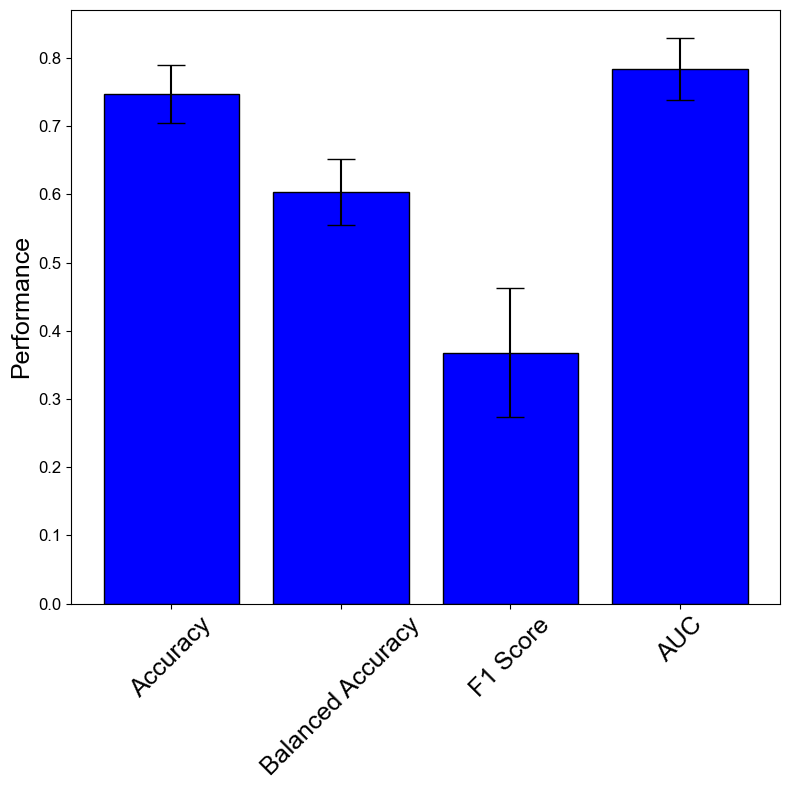

[0.74765625 0.60366621 0.36821037 0.78394719]
[0.0422092  0.04859367 0.09425058 0.04511265]


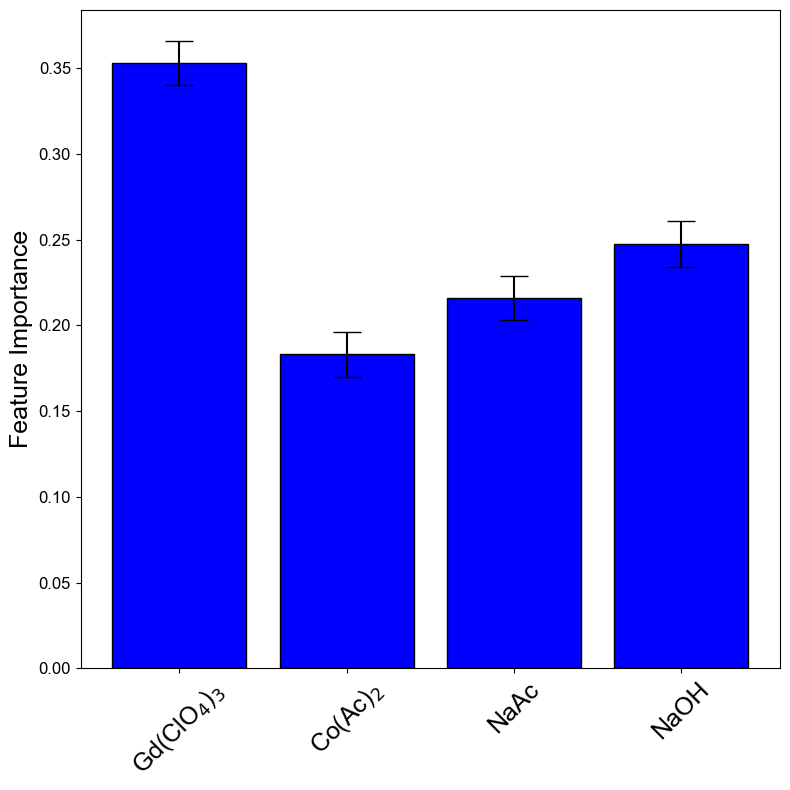

[0.35299847 0.18320037 0.21613785 0.24766331]
[0.01267824 0.01314605 0.01272082 0.01338341]


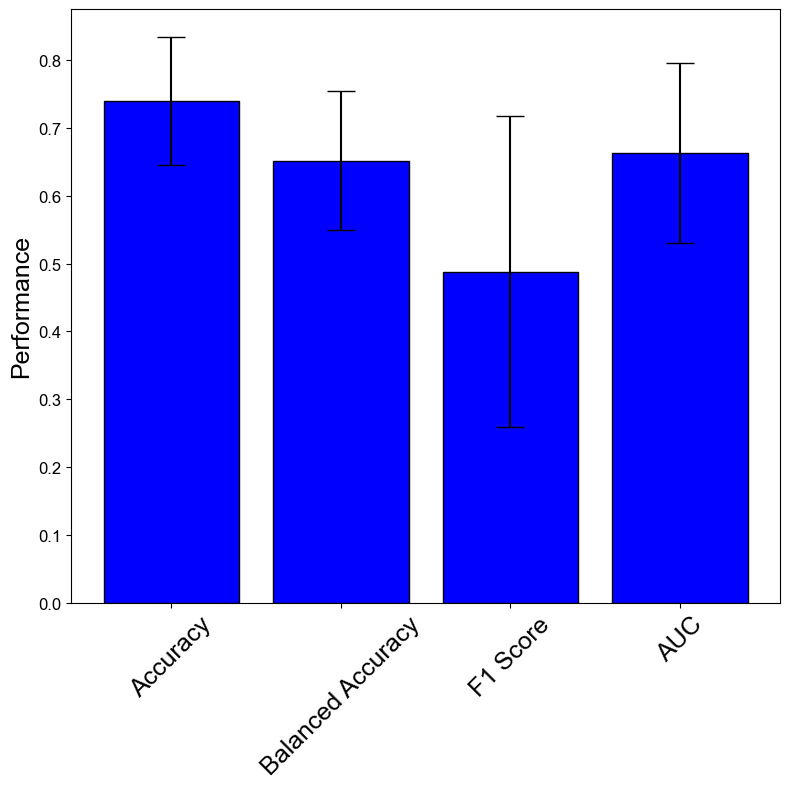

[0.74013158 0.65191929 0.48816284 0.66266561]
[0.09390857 0.10228013 0.22974235 0.13285902]


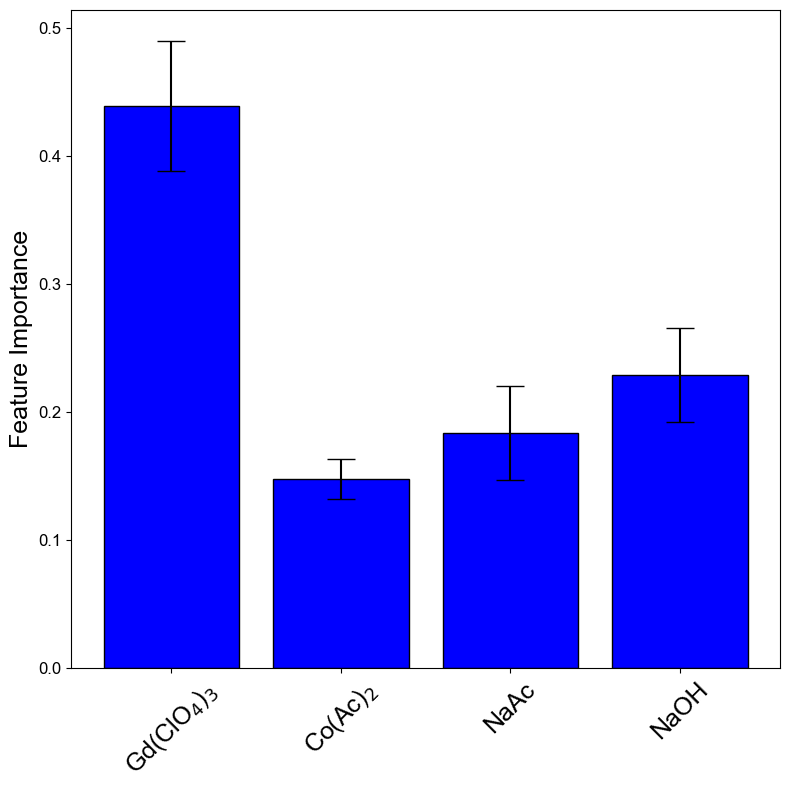

[0.43897817 0.14807798 0.18385208 0.22909178]
[0.05061622 0.01579051 0.03655064 0.03667598]


(array([0.43897817, 0.14807798, 0.18385208, 0.22909178]),
 array([0.05061622, 0.01579051, 0.03655064, 0.03667598]))

In [5]:
from plot_tools import plot_performance, plot_feature_importance
all_RFperformance1 = np.array(all_RFperformance1)
all_RFperformance2 = np.array(all_RFperformance2)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
plot_performance(all_RFperformance1)
plot_feature_importance(feature_importance1, feature_names)
plot_performance(all_RFperformance2)
plot_feature_importance(feature_importance2, feature_names)

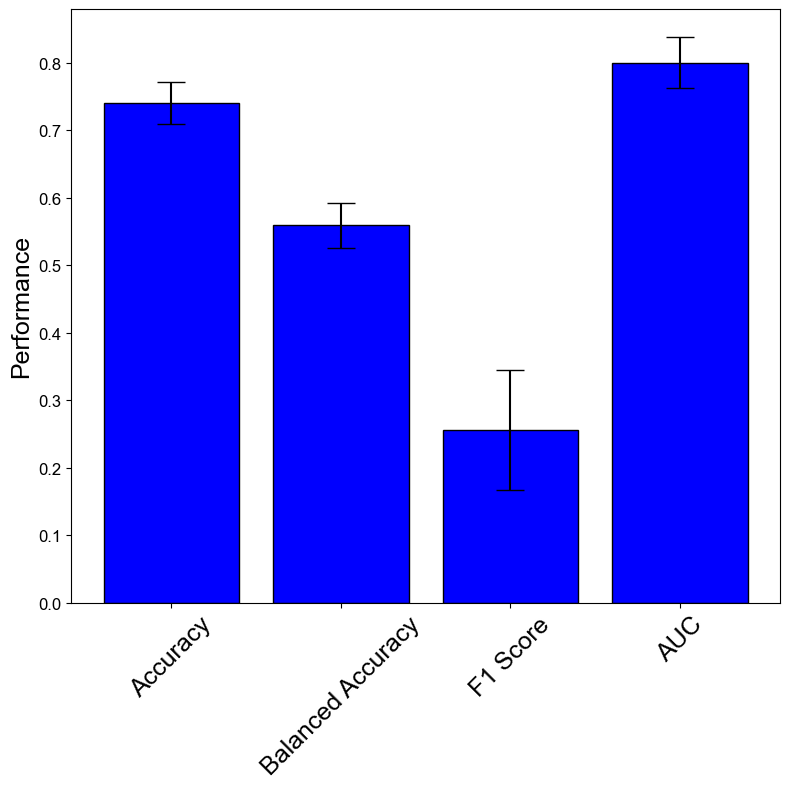

[0.740625   0.55876876 0.25634912 0.80008694]
[0.03140586 0.03363459 0.08882418 0.03757857]


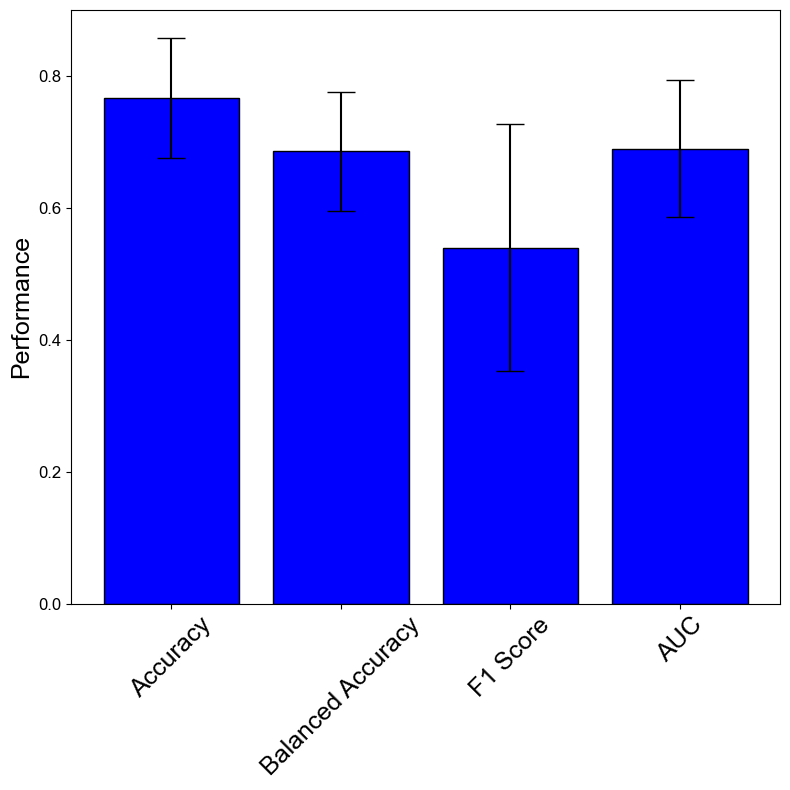

[0.76644737 0.68610712 0.5395979  0.68962709]
[0.0911012  0.0903339  0.18732538 0.10389367]


(array([0.76644737, 0.68610712, 0.5395979 , 0.68962709]),
 array([0.0911012 , 0.0903339 , 0.18732538, 0.10389367]))

In [6]:
from plot_tools import plot_performance
all_LSperformance1 = np.array(all_LSperformance1)
all_LSperformance2 = np.array(all_LSperformance2)
plot_performance(all_LSperformance1)
plot_performance(all_LSperformance2)

(<Figure size 2400x2400 with 2 Axes>,
 <Axes: xlabel='Gd(ClO$_4$)$_3$', ylabel='NaOH'>)

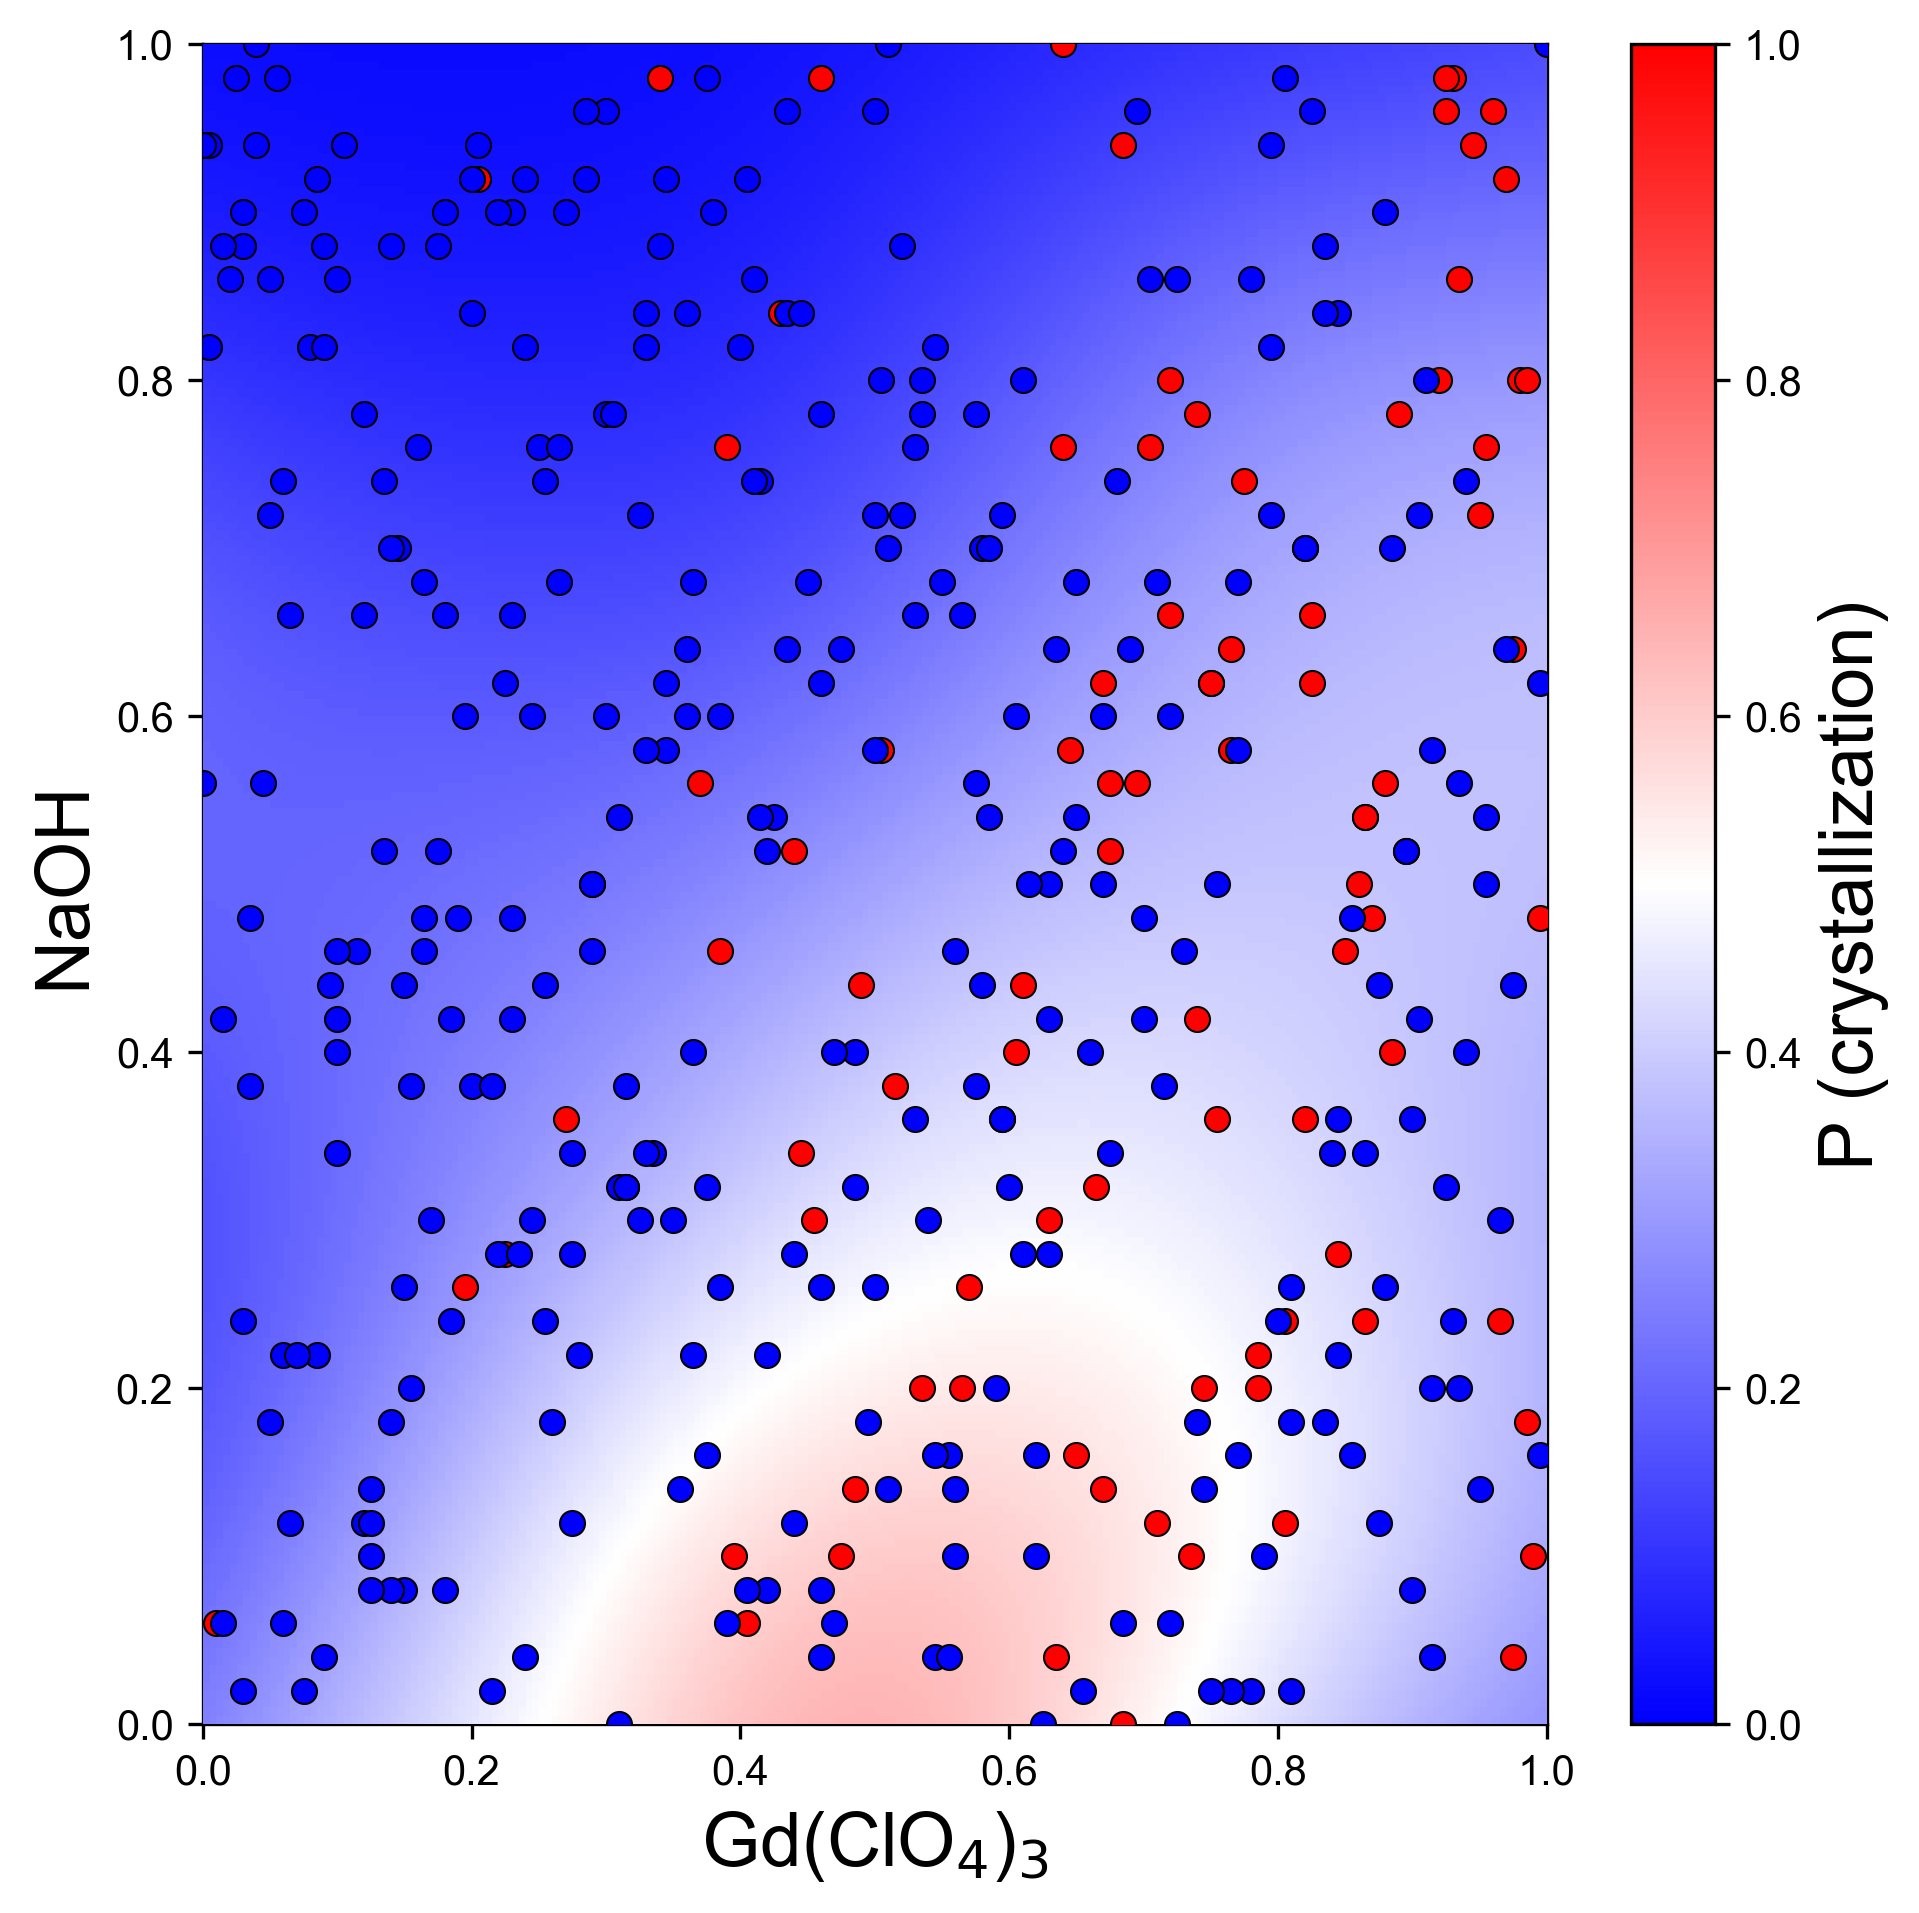

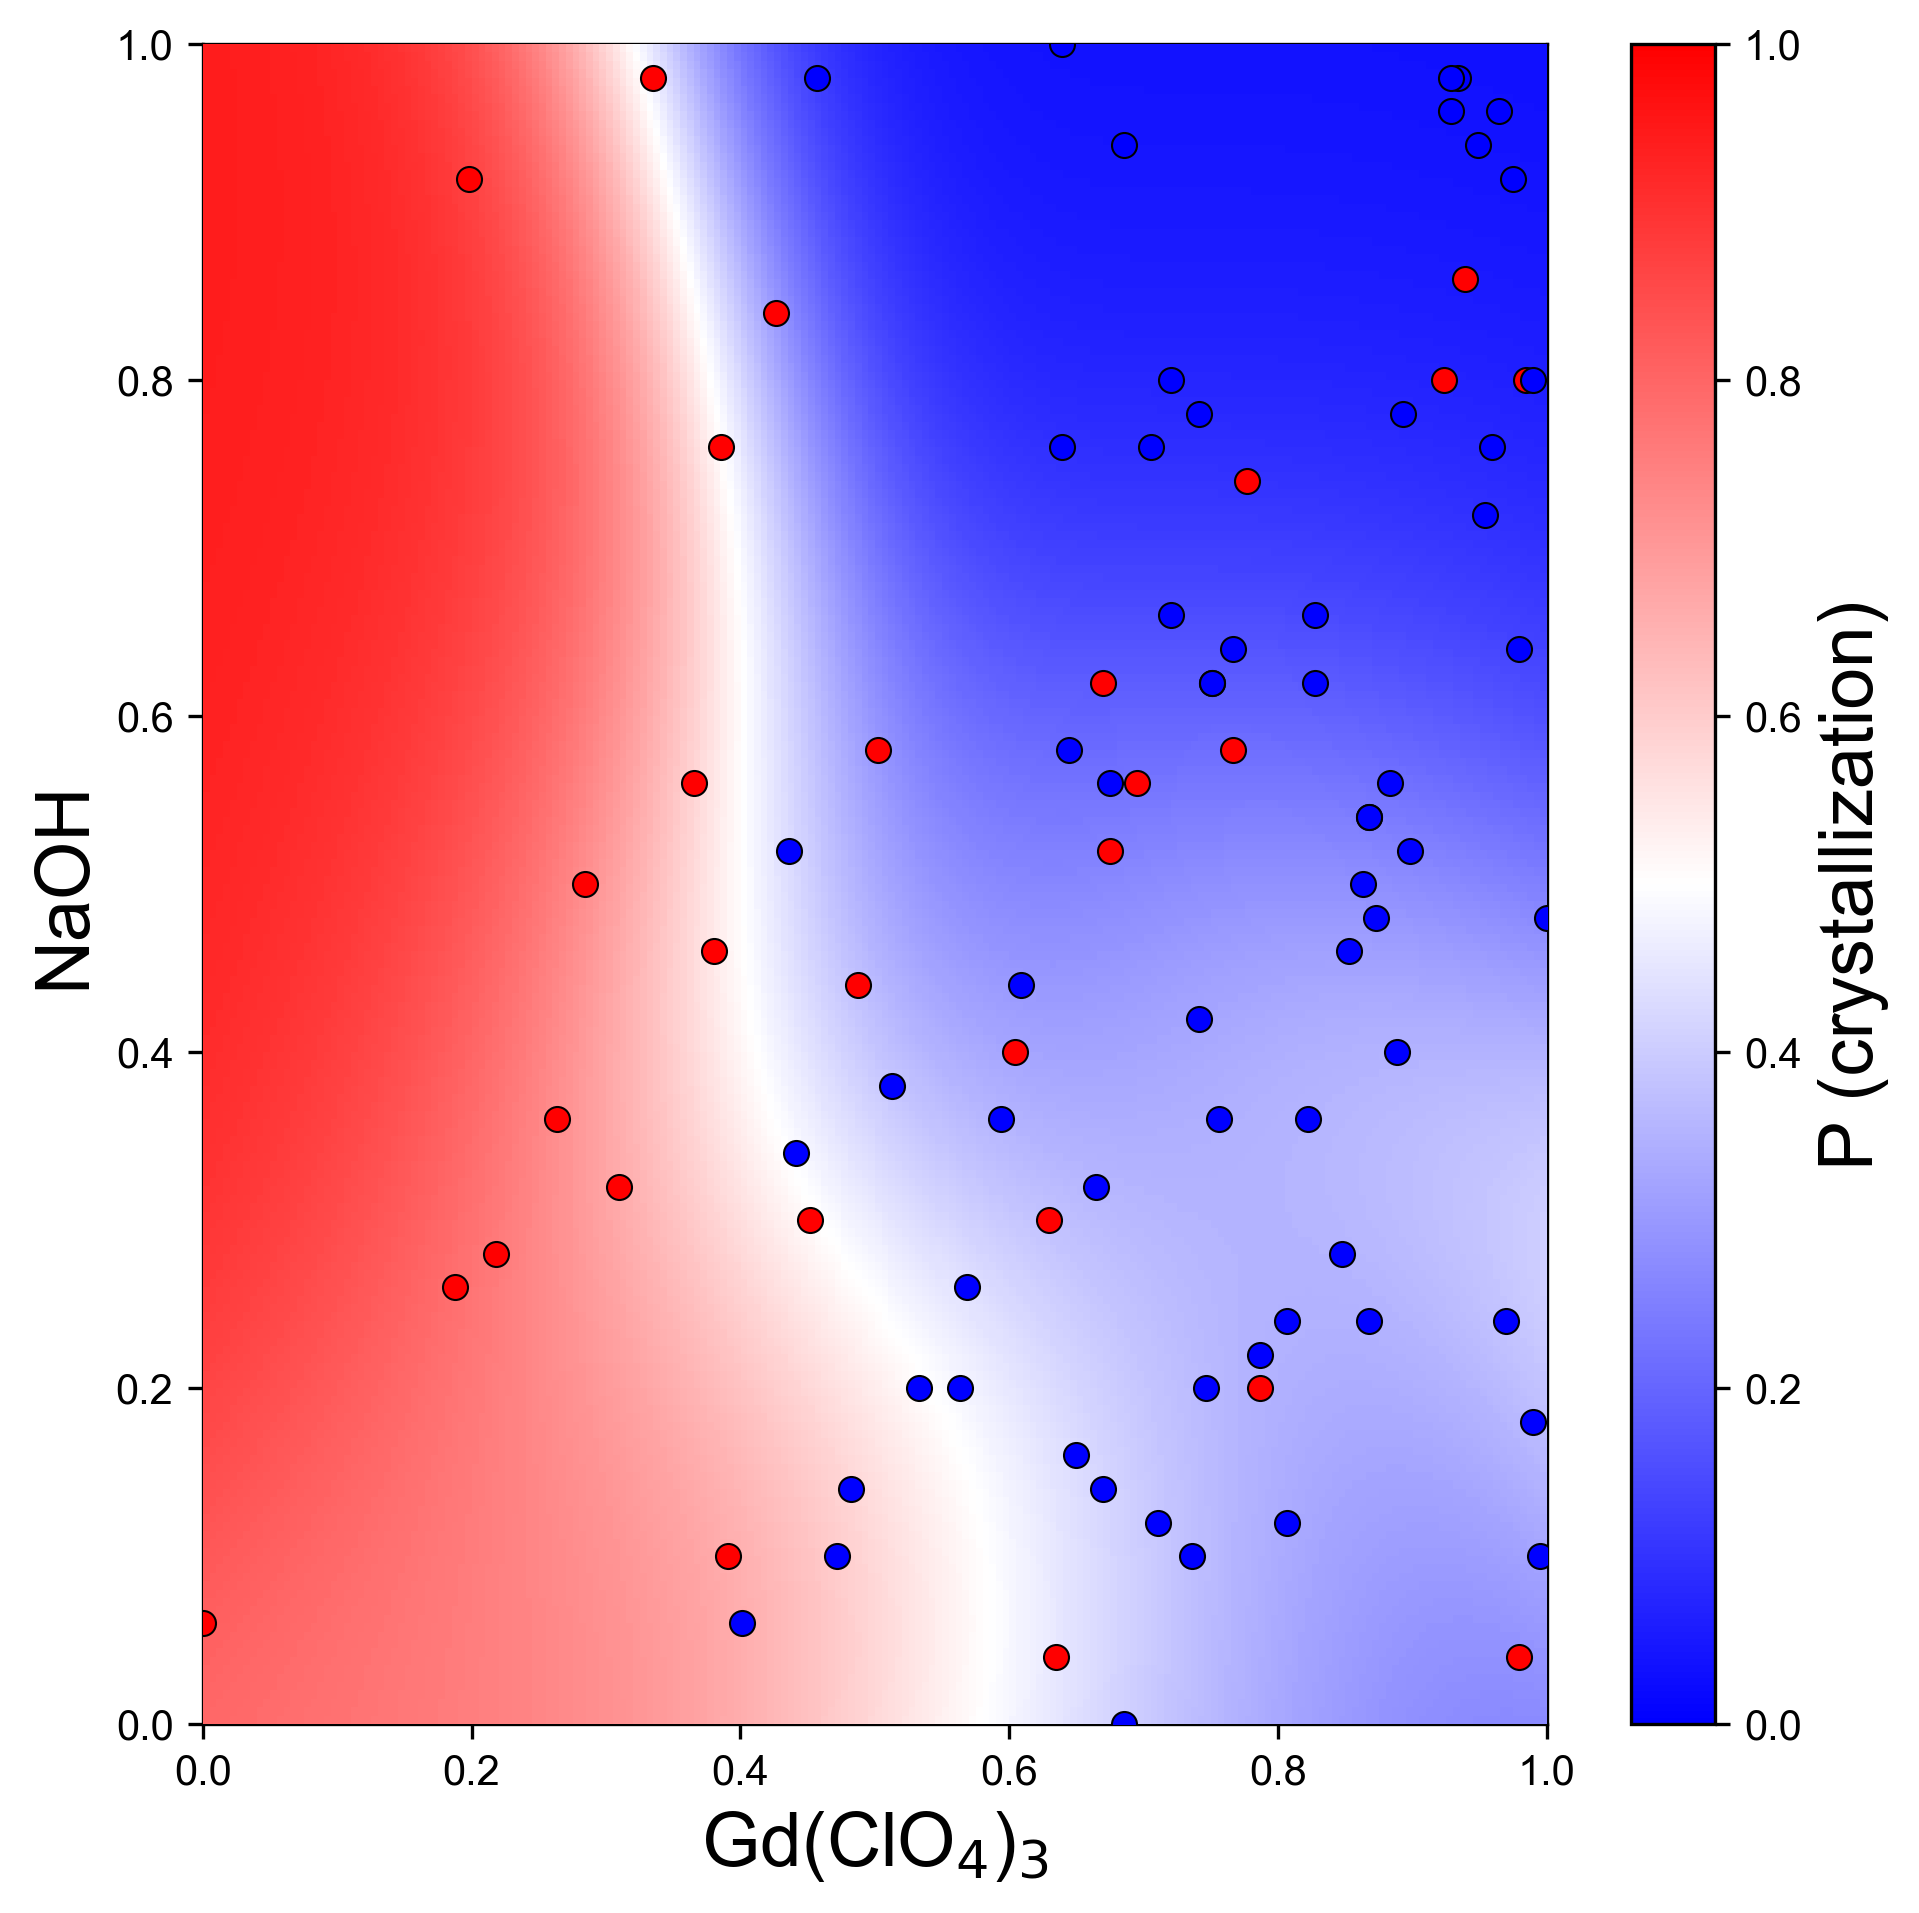

In [11]:
from plot_tools import plot_phase_diagram, create_prediction_grid
dimension_index = [0, 3]  # 选择要绘制的两个自由维度索引
X_grid, grid_shape = create_prediction_grid(
    fixed_dims=[1, 2], #选择固定的特征索引
    fixed_vals=[0.25, 0.25], #固定特征的值（选定切片位置）
    resolution=200  # 200^2 = 40000个点
)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
#做切片
plot_phase_diagram(LS_model1, X_grid, grid_shape, norm_X1, Y1, dimension_index, feature_names)
plot_phase_diagram(LS_model2, X_grid, grid_shape, norm_X2, Y2, dimension_index, feature_names)